In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import datetime as dt


In [ ]:
pip install kagglehub

# Load data

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "2019-Oct.csv"

# Loading dataset with pandas kwargs
df = kagglehub.load_dataset(
KaggleDatasetAdapter.PANDAS,
"mkechinov/ecommerce-behavior-data-from-multi-category-store",
"2019-Oct.csv",
pandas_kwargs={
"nrows": 500_000,
"dtype": {
'event_type': 'category',
'product_id': 'int32',
'category_code': 'category',
'brand': 'category',
'price': 'float32',
'user_id': 'int32',
}
}
)


/home/sophie/.pyenv/versions/3.10.6/envs/convertiq/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_67127/1897145881.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df = df.drop_duplicates()

In [63]:
df.shape

(499712, 9)

In [3]:
df['event_time'] = pd.to_datetime(df['event_time'])

In [4]:
cut_time = df['event_time'].median()

In [5]:
cut_time

Timestamp('2019-10-01 06:52:15+0000', tz='UTC')

In [6]:
past   = df[df['event_time'] <= cut_time]
future = df[df['event_time'] >  cut_time]

In [4]:
list_category_code = ['electronics.smartphone',
'electronics.audio.headphone',
'electronics.clocks',
'computers.notebook',
'electronics.video.tv'
]


In [5]:
df_elec=df[df['category_code'].isin(list_category_code)]

In [ ]:
df_elec['date'] = df_elec['event_time'].apply(lambda s : str(s)[0:10])

In [ ]:
df_elec['hour'] = df_elec['event_time'].apply(lambda s : str(s)[10:19])

In [ ]:

df_elec['date'] = pd.to_datetime(df_elec['date'])

In [ ]:
df_elec['week_of_day'] = df_elec['date'].dt.day_name()

In [6]:
df_elec['event_type_str'] = df_elec['event_type'].astype(str)
df_elec.sort_values(by=['user_id', 'user_session', 'product_id', 'event_time'])
df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


/tmp/ipykernel_67127/1888376266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_type_str'] = df_elec['event_type'].astype(str)
/tmp/ipykernel_67127/1888376266.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time']=pd.to_datetime(df_elec['event_time'])


In [ ]:

df_events_v2 = df_elec.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(8)
              ], index=['event1', 'event2', 'event3','event4', 'event5', 'event6','event7', 'event8' ])).reset_index()
df_events_v2.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str')
df_events_v2.head(10)

In [11]:
df_elec['event_time'] = df_elec['event_time'].astype(str)

/tmp/ipykernel_6220/1570059409.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_elec['event_time'] = df_elec['event_time'].astype(str)


In [ ]:
df_events_v2_pivot = df_events_v2.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_type_str').reset_index()

In [ ]:
df_events_v2_pivot.head(10)

#Buliding sequence of events

In [ ]:
#time sequence per user id, user session
df_events_time = df_elec.groupby(['user_id', 'user_session'])['event_time'].apply(lambda x: pd.Series([x.iloc[i] if i < len(x) else ' ' for i in range(8)
              ], index=['time1', 'time2', 'time3','time4', 'time5', 'time6','time7', 'time8' ])).reset_index()
df_events_time_pivot = df_events_time.pivot(index=['user_id', 'user_session'], columns='level_2', values='event_time').reset_index()
df_events_time_pivot.head(10)

In [15]:
#event sequence and duration mean per user id, user session
import numpy as np
df_events = df_elec.groupby(['user_id', 'user_session', 'category_id']).agg({
    'event_type_str' : " ".join,
    'event_time' : (lambda x : max(x) - min(x)),
    'product_id' : (lambda x : np.size(x))
}).reset_index()

In [16]:
df_events.head()

,user_id,user_session,category_id,event_type_str,event_time,product_id
0,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2053013555631882655,view view,0 days 00:00:53,2
1,362972137,a7d81604-ed16-4bf2-afc3-386d12f26547,2053013555631882655,view view view,0 days 00:04:07,3
2,376375533,e0b2446d-e6fa-4993-a0f6-2efbde5f3d93,2053013554658804075,view view view,0 days 00:03:44,3
3,386070015,49d03116-3c95-4e13-8b9c-e3be97551fe8,2053013555631882655,view view view cart view,0 days 00:02:33,5
4,390315979,8efe5b01-a233-424e-b801-b34e50bc9478,2053013554658804075,view,0 days 00:00:00,1


In [17]:
df_events['seq_list'] = df_events['event_type_str'].apply(str.split)
df_events['seq_list_1'] = df_events['seq_list'].apply(lambda x : x[:-1])
df_events['target'] = df_events['seq_list'].apply(lambda x : x[-1])
df_events ['seq_one'] = df_events['seq_list_1'].apply(lambda x : ['one_view'] if x==[] else x)
df_events['seq'] = df_events.agg({'seq_one' : " ".join })




#df_events['seq_1'] = df_events.groupby(['user_id', 'user_session'])['seq_list'].apply(lambda x: x[:-1])

#df_events_time['target'] = df_events.groupby(['user_id', 'user_session'])['event_type_str'].apply(lambda x: x[-1])

/tmp/ipykernel_67127/3806566200.py:5: FutureWarning: using <built-in method join of str object at 0x7ea893dc0070> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df_events['seq'] = df_events.agg({'seq_one' : " ".join })


In [ ]:
#df_events['event_time_list'] = df_events['event_time'].apply(str.split)
#df_events['event_time_1'] = df_events['event_time_list'].apply(lambda x : x[:-1])
#df_events['time_to target'] = df_events['event_time_list'].apply(lambda x : x[-1])
#df_events['seq'] = df_events.agg({'seq_list_1' : " ".join })

In [268]:
df_events.shape

(55094, 10)

In [ ]:
#df_events_2 = pd.merge(df_events, df_elec.loc[:,['user_id', 'user_session', 'product_id', 'event_time']], on=['user_id', 'user_session', 'product_id'], how='left')

In [269]:
df_events['target'].value_counts()

target
view        52301
purchase     2005
cart          788
Name: count, dtype: int64

In [19]:
df_events['target_0_1'] = df_events['target'].apply(lambda x : 1 if x=='purchase' else 0)

In [20]:
df_events['target_0_1'].value_counts(normalize=True)

target_0_1
0    0.963608
1    0.036392
Name: proportion, dtype: float64

In [21]:
df_events = df_events.rename(columns={'event_time':'duration', 'product_id' : 'nb_product'})

In [22]:
#sequence length definition event_len
df_events['sequence_len'] = df_events['seq'].apply(lambda x : len(x.split()))

In [23]:
df_events.describe()

,user_id,category_id,duration,nb_product,target_0_1,sequence_len
count,5.509400e+04,5.509400e+04,55094,55094.000000,55094.000000,55094.000000
mean,5.335460e+08,2.053047e+18,0 days 00:03:56.660525647,3.486786,0.036392,2.881294
std,1.710318e+07,1.372117e+15,0 days 00:15:40.172830893,4.548015,0.187266,4.354442
min,2.449511e+08,2.053014e+18,0 days 00:00:00,1.000000,0.000000,1.000000
25%,5.164016e+08,2.053014e+18,0 days 00:00:00,1.000000,0.000000,1.000000
50%,5.326711e+08,2.053014e+18,0 days 00:00:40,2.000000,0.000000,1.000000
75%,5.516653e+08,2.053014e+18,0 days 00:02:55,4.000000,0.000000,3.000000
max,5.555840e+08,2.109094e+18,0 days 08:59:23,139.000000,1.000000,138.000000


In [24]:
#computation of duration mean per user_id, user session duration_mean
df_events['duration_mean']=df_events['duration']/df_events['sequence_len']
df_events['duration_mean_sec'] = df_events['duration_mean'].dt.total_seconds()

In [25]:
#building of y dataframe
y = df_events['target_0_1']
#y_small = pd.DataFrame(df_event_feature_small['target_0_1'])

In [26]:
y.shape

(55094,)

In [27]:
df_events.head(5)

,user_id,user_session,category_id,event_type_str,duration,nb_product,seq_list,seq_list_1,target,seq_one,seq,target_0_1,sequence_len,duration_mean,duration_mean_sec
0,244951053,91769fdf-461b-4e43-9c73-88a07481b75c,2053013555631882655,view view,0 days 00:00:53,2,"[view, view]",[view],view,[view],view,0,1,0 days 00:00:53,53.00
1,362972137,a7d81604-ed16-4bf2-afc3-386d12f26547,2053013555631882655,view view view,0 days 00:04:07,3,"[view, view, view]","[view, view]",view,"[view, view]",view view,0,2,0 days 00:02:03.500000,123.50
2,376375533,e0b2446d-e6fa-4993-a0f6-2efbde5f3d93,2053013554658804075,view view view,0 days 00:03:44,3,"[view, view, view]","[view, view]",view,"[view, view]",view view,0,2,0 days 00:01:52,112.00
3,386070015,49d03116-3c95-4e13-8b9c-e3be97551fe8,2053013555631882655,view view view cart view,0 days 00:02:33,5,"[view, view, view, cart, view]","[view, view, view, cart]",view,"[view, view, view, cart]",view view view cart,0,4,0 days 00:00:38.250000,38.25
4,390315979,8efe5b01-a233-424e-b801-b34e50bc9478,2053013554658804075,view,0 days 00:00:00,1,[view],[],view,[one_view],one_view,0,1,0 days 00:00:00,0.00


In [28]:
aux=df_events.loc[:,['category_id', 'seq','duration_mean_sec', 'sequence_len', 'nb_product']]

In [29]:
aux.head()

,category_id,seq,duration_mean_sec,sequence_len,nb_product
0,2053013555631882655,view,53.00,1,2
1,2053013555631882655,view view,123.50,2,3
2,2053013554658804075,view view,112.00,2,3
3,2053013555631882655,view view view cart,38.25,4,5
4,2053013554658804075,one_view,0.00,1,1


In [30]:
X = df_events.loc[:,['category_id', 'seq','duration_mean_sec', 'sequence_len', 'nb_product']]

In [31]:
X.head(5)

,category_id,seq,duration_mean_sec,sequence_len,nb_product
0,2053013555631882655,view,53.00,1,2
1,2053013555631882655,view view,123.50,2,3
2,2053013554658804075,view view,112.00,2,3
3,2053013555631882655,view view view cart,38.25,4,5
4,2053013554658804075,one_view,0.00,1,1


In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

In [236]:
y_test = y_test[:,0]

In [33]:
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn.preprocessing import OneHotEncoder, RobustScaler

pipe_cat = Pipeline([('ohe',OneHotEncoder(sparse_output=False,

                        handle_unknown="ignore").set_output(transform="pandas"))])


In [34]:
pipe_num = Pipeline([('rb_scale', RobustScaler().set_output(transform="pandas"))])

In [35]:
col_transf = ColumnTransformer([
    ('cat_transform',pipe_cat, ["category_id", "seq", "nb_product"]),
    ('num_transform', pipe_num, ['sequence_len', 'duration_mean_sec'])
])

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score
pipe = Pipeline([
    ("preprocessing", col_transf),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [37]:
cv_result = cross_validate(pipe, X_train, y_train, cv = 5, scoring = ['precision', 'recall', 'f1'])

In [43]:
encoder = OneHotEncoder(sparse_output=False,

                        handle_unknown="ignore").set_output(transform="pandas")

X_train_encoder = encoder.fit_transform(X_train[['seq', 'category_id']])
X_test_encoder = encoder.transform(X_test[['seq', 'category_id']])


In [44]:
rb_scaler = RobustScaler().set_output(transform = "pandas")

X_train_scaled = rb_scaler.fit_transform(X_train[[ 'sequence_len', 'duration_mean_sec', 'nb_product']])
X_test_scaled = rb_scaler.transform(X_test[[ 'sequence_len', 'duration_mean_sec', 'nb_product']])

In [45]:
X_train_preprocessed = pd.concat([X_train_encoder, X_train_scaled],axis=1)

In [46]:
X_test_preprocessed = pd.concat([X_test_encoder, X_test_scaled],axis=1)

# Baseline model Regression Logistique

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_predict, cross_val_score


model = pipe.fit(X_train, y_train)


In [77]:
cv_result = cross_validate(pipe, X_train, y_train, cv = 2, scoring = ['precision', 'recall', 'f1'])

KeyboardInterrupt: 

In [66]:
cv_result['test_precision'].mean()

np.float64(0.1488696444847958)

In [67]:
cv_result['test_recall'].mean()

np.float64(0.673170731707317)

In [68]:
cv_result['test_f1'].mean()

np.float64(0.23945344943970887)

In [70]:
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve

cv = StratifiedKFold(n_splits=5)
cross_v_result = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="average_precision").mean()


In [71]:
cross_v_result

np.float64(0.36405817375456817)

In [82]:
y_pred_prob = pipe.predict_proba(X_test)


In [85]:
y_pred_prob= y_pred_prob[:,1]

In [83]:
precision, recall, _= precision_recall_curve(y_test, y_pred_prob)

ValueError: y should be a 1d array, got an array of shape (11019, 2) instead.

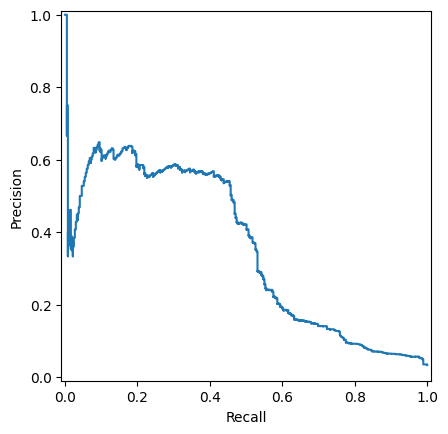

In [81]:

disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot();

In [ ]:
cross_v_result

np.float64(0.3634476473578629)

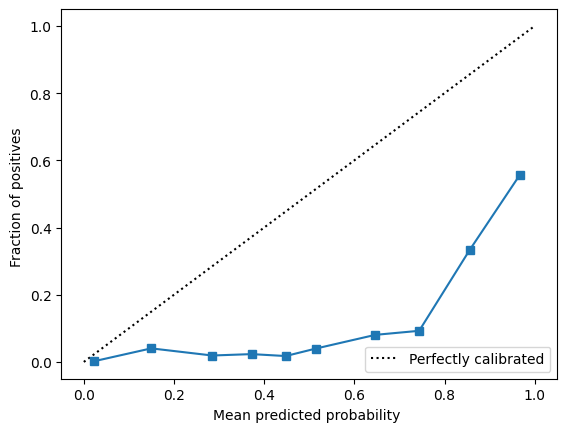

In [86]:
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob)
disp.plot();

In [87]:
calibrated_clf = CalibratedClassifierCV(pipe, cv=cv)
calibrated_clf.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred_prob = calibrated_clf.predict_proba(X_test)


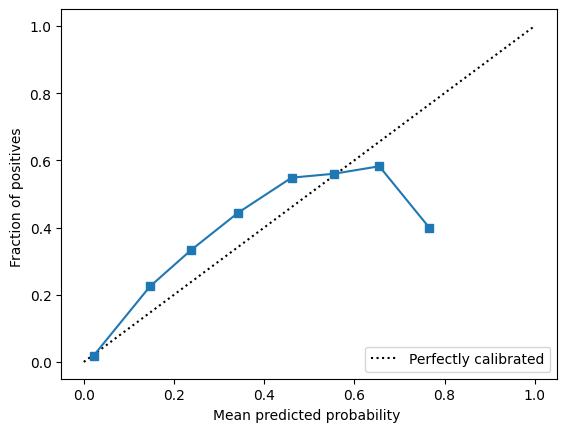

In [58]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob[:,1], n_bins=10)

disp = CalibrationDisplay(prob_true, prob_pred, y_pred_prob[:,1])
disp.plot();

In [60]:
pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn][imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [61]:

from imblearn.under_sampling import TomekLinks

In [64]:


tl = TomekLinks()
X_train_res, y_train_res = tl.fit_resample(X_train_preprocessed, y_train)

print(X_train_res.shape)
print(y_train_res.shape)


(43777, 912)
(43777,)


In [63]:
y_train_res.value_counts(normalize=True)

target_0_1
0    0.962537
1    0.037463
Name: proportion, dtype: float64

In [ ]:
feature_names = list(X_train.columns)

In [ ]:
feature_names

['seq_cart',
 'seq_cart cart',
 'seq_cart cart cart cart cart cart',
 'seq_cart cart cart purchase',
 'seq_cart cart cart view view',
 'seq_cart cart purchase',
 'seq_cart cart view',
 'seq_cart cart view cart purchase view',
 'seq_cart purchase',
 'seq_cart purchase view',
 'seq_cart view',
 'seq_cart view cart cart cart',
 'seq_cart view cart cart cart view view cart view',
 'seq_cart view view',
 'seq_purchase',
 'seq_purchase purchase view',
 'seq_purchase view',
 'seq_purchase view cart',
 'seq_purchase view cart purchase',
 'seq_purchase view purchase view',
 'seq_purchase view view',
 'seq_purchase view view view',
 'seq_view',
 'seq_view cart',
 'seq_view cart cart',
 'seq_view cart cart cart',
 'seq_view cart cart cart cart',
 'seq_view cart cart cart cart cart',
 'seq_view cart cart cart cart cart cart',
 'seq_view cart cart cart cart cart cart cart',
 'seq_view cart cart cart cart cart cart cart cart cart cart',
 'seq_view cart cart cart cart cart cart cart cart cart cart ca

In [ ]:
from sklearn.inspection import permutation_importance
r = permutation_importance(log_reg, X_train, y_train,
                           n_repeats=5,
                           random_state=0)
for i in r.importances_mean.argsort()[::-1]:
    #if r.importances_mean[i] - 2 * r.importances_std[i] > 0:
    print(f"{feature_names[i]:<8}"
            f"{r.importances_mean[i]:.3f}"
            f" +/- {r.importances_std[i]:.3f}")

KeyboardInterrupt: 

In [ ]:
r.importances_mean

In [ ]:
ft_importance = pd.DataFrame(r.importances_mean, feature_names).reset_index()

In [ ]:
ft_importance.head(10)

In [ ]:
X_train_preprocessed.shape

(44075, 920)

In [88]:
import numpy as np
from sklearn.model_selection import learning_curve

train_sizes = [7500, 10000,15000, 20000, 25000, 30000]

# Get train scores (R2), train sizes, and validation scores using `learning_curve`
train_sizes, train_scores, test_scores = learning_curve(
    estimator=pipe, X=X_train, y=y_train, train_sizes=train_sizes, cv=5, scoring="recall")

# Take the mean of cross-validated train scores and validation scores
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)


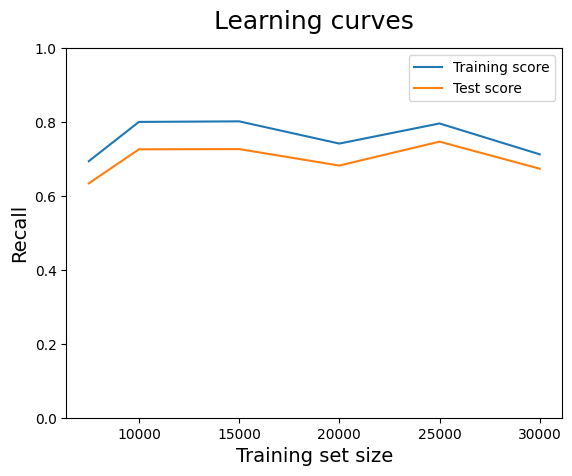

In [89]:
plt.plot(train_sizes, train_scores_mean, label = 'Training score')
plt.plot(train_sizes, test_scores_mean, label = 'Test score')
plt.ylim(0, 1)
plt.ylabel('Recall', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves', fontsize = 18, y = 1.03)
plt.legend()